# Equity Data — Explanation Notebook

This notebook demonstrates the equity data layer that feeds the portfolio
risk engine. It loads daily closing prices for four equities, derives
returns and summary statistics, and inspects the diversification structure
of the basket.

The four tickers — NAB.AX, BHP.AX, CSL.AX, WOW.AX — span four distinct GICS sectors of the ASX 200: financials, materials, healthcare, and consumer staples. They were chosen to give the portfolio a non-trivial correlation structure: NAB and BHP move with broad domestic risk sentiment and should show moderate positive co-movement, while CSL (a global biotech with USD-denominated revenue) and WOW (defensive domestic staples) bring lower-correlation exposures that make the diversification benefit in portfolio VaR observable rather than incidental.

What to look for:

- A populated price panel covering 5 years of trading days
- Annualised volatilities in a sensible range (~15–30% for ASX large caps)
- A correlation matrix where all pairwise correlations sit between roughly 0 and 0.25, with the lowest pairings between names whose earnings drivers genuinely diverge (e.g. mining vs healthcare)
- Return distributions that are approximately normal but with visible fat tails

In [1]:
# Setup
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.equity_data import (
    load_equity_panel,
    compute_log_returns,
    summary_table,
    correlation_matrix,
)

TICKERS = ["NAB.AX", "BHP.AX", "CSL.AX", "WOW.AX"]
START_DATE = "2021-05-19"
END_DATE = "2026-05-19"

## 1. Equity spot and history

We load 5 years of daily closing prices for the three tickers. The loader
checks a local CSV cache first (`data/equities/<TICKER>.csv`) and falls
back to Yahoo Finance only on cache miss. This makes the notebook fully
reproducible offline once the cache is populated, and avoids hitting
yfinance's rate limit on repeated runs.


In [2]:
# Load price panel for all three tickers (reads from local cache -> offline run)
# cache_dir is resolved relative to the repo root, since the notebook runs from notebooks/
CACHE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "equities"))

panel = load_equity_panel(TICKERS, START_DATE, END_DATE, cache_dir=CACHE_DIR)
panel.tail()


Loaded 1265 daily observations for NAB.AX from yfinance (NAB.AX)
  Date range: 2021-05-19 to 2026-05-19
  Latest close: 37.04
Loaded 1265 daily observations for BHP.AX from yfinance (BHP.AX)
  Date range: 2021-05-19 to 2026-05-19
  Latest close: 58.70
Loaded 1265 daily observations for CSL.AX from yfinance (CSL.AX)
  Date range: 2021-05-19 to 2026-05-19
  Latest close: 98.69
Loaded 1265 daily observations for WOW.AX from yfinance (WOW.AX)
  Date range: 2021-05-19 to 2026-05-19
  Latest close: 34.21


,NAB.AX,BHP.AX,CSL.AX,WOW.AX
Date,,,,
2026-05-13,36.860001,61.520000,98.790001,32.959999
2026-05-14,36.419998,62.060001,97.260002,32.540001
2026-05-15,36.520000,60.459999,97.959999,32.980000
2026-05-18,36.320000,58.770000,96.220001,32.980000
2026-05-19,37.040001,58.700001,98.690002,34.209999


## 2. Summary diagnostics

For each ticker we compute:
- **spot**: the latest closing price
- **ann_vol**: annualised volatility, estimated from daily log returns
  using $\sigma_\text{ann} = \sigma_\text{daily} \times \sqrt{252}$
- **n_obs**: number of return observations (one less than price obs)


In [3]:
returns = compute_log_returns(panel)
summary = summary_table(panel, returns)
summary.round(4)


,spot,ann_vol,n_obs
NAB.AX,37.04,0.1957,1264.0
BHP.AX,58.70,0.2589,1264.0
CSL.AX,98.69,0.2510,1264.0
WOW.AX,34.21,0.1988,1264.0


**Interpretation.** Annualised volatilities split cleanly into two bands. NAB and WOW sit at ~20%, consistent with their defensive, domestic-revenue profiles (regulated banking and consumer staples). BHP and CSL sit higher at ~25–26%, reflecting their cyclical and global exposures — BHP to commodity prices and Chinese demand, CSL to global healthcare flows and FX. All four tickers have identical observation counts (1,264 daily returns over the 5-year window), confirming the inner-join alignment in the panel worked cleanly with no missing days.


## 3. Price history

To compare relative performance, we normalise each price series to 100 at the start of the window. This shows percentage growth from a common base, removing the obvious scale differences (CSL at ~$98 vs WOW at ~$34) and letting us read the four trajectories on a single axis.


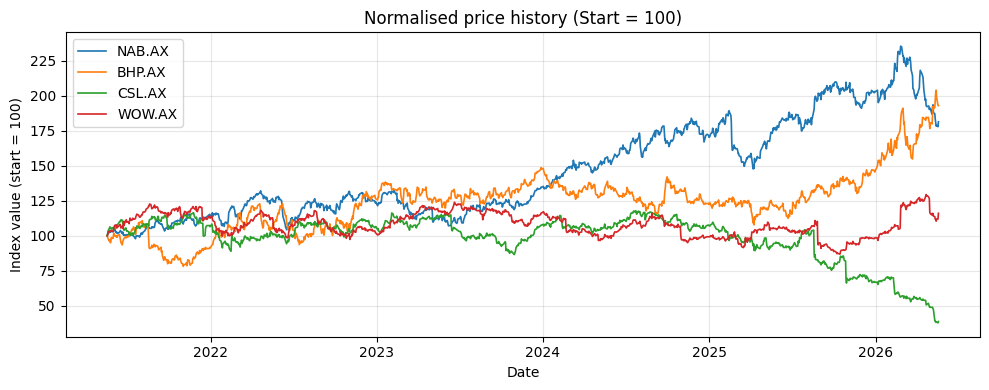

In [4]:
# Normalise each ticker to 100 at the start of the window
normalised = panel / panel.iloc[0] * 100

fig, ax = plt.subplots(figsize=(10, 4))
for ticker in TICKERS:
    ax.plot(normalised.index, normalised[ticker], label=ticker, linewidth=1.2)

ax.set_title("Normalised price history (Start = 100)")
ax.set_xlabel("Date")
ax.set_ylabel("Index value (start = 100)")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Return distributions

We plot the daily log return distribution for each of the four tickers. Parametric VaR assumes returns are approximately normal — these histograms let us check visually whether that assumption is defensible, and where it breaks down.


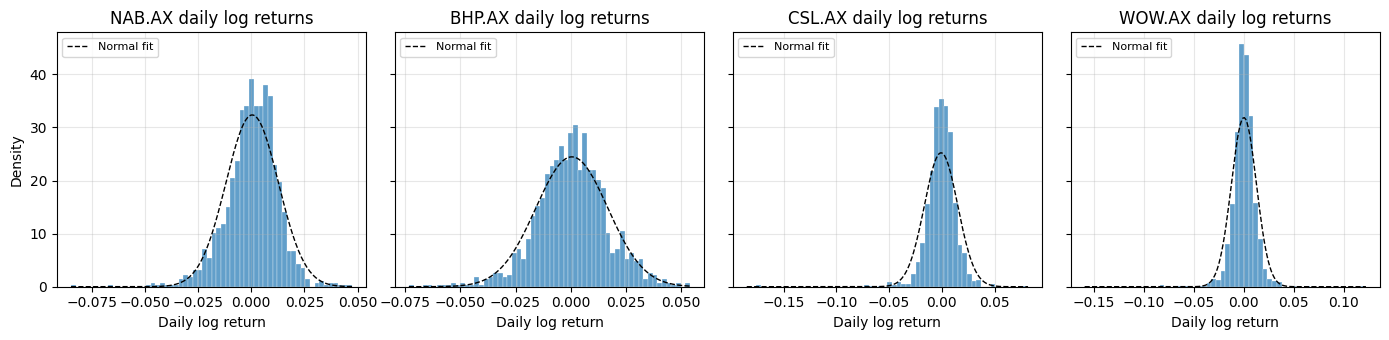

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)

for ax, ticker in zip(axes, TICKERS):
    r = returns[ticker]
    ax.hist(r, bins=60, density=True, alpha=0.7, edgecolor="white", linewidth=0.3)
    # Overlay a normal density for visual comparison
    x = np.linspace(r.min(), r.max(), 200)
    pdf = (1 / (r.std() * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - r.mean()) / r.std()) ** 2)
    ax.plot(x, pdf, "k--", linewidth=1, label="Normal fit")
    ax.set_title(f"{ticker} daily log returns")
    ax.set_xlabel("Daily log return")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Density")
plt.tight_layout()
plt.show()


**Interpretation.** All four empirical distributions are roughly bell-shaped and centred near zero, consistent with the normal assumption underlying parametric VaR. However, every ticker shows **fat tails** — extreme returns occur more often than a normal distribution would predict. The effect is most visible in CSL, which has a clear left-tail outlier near –15% from a single-day drawdown, but is present in all four names. This is a well-known limitation of the parametric approach and motivates running historical VaR alongside it: historical VaR captures these realised extremes directly without imposing a parametric shape.


## 5. Correlation matrix

The pairwise correlation of daily log returns drives portfolio diversification.
A diagonal of 1s and meaningful off-diagonal structure is what we want for
the portfolio risk story.


In [6]:
corr = correlation_matrix(returns)
corr.round(4)


,NAB.AX,BHP.AX,CSL.AX,WOW.AX
NAB.AX,1.0000,0.1818,0.1830,0.2358
BHP.AX,0.1818,1.0000,0.0450,0.1059
CSL.AX,0.1830,0.0450,1.0000,0.1946
WOW.AX,0.2358,0.1059,0.1946,1.0000


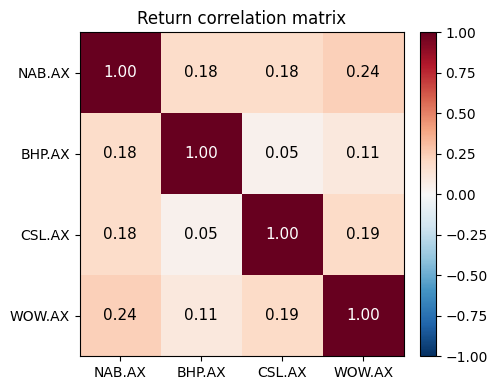

In [7]:
# Heatmap of the correlation matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(TICKERS)))
ax.set_yticks(range(len(TICKERS)))
ax.set_xticklabels(TICKERS)
ax.set_yticklabels(TICKERS)

# Annotate each cell with the correlation value
for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}",
                ha="center", va="center",
                color="white" if abs(corr.values[i, j]) > 0.5 else "black",
                fontsize=11)

ax.set_title("Return correlation matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


**Interpretation.** The off-diagonal correlations are all weak — the highest pair is NAB–WOW at 0.24, and most pairs sit between 0.05 and 0.20. BHP is essentially uncorrelated with the other three names (0.18, 0.05, 0.11), reflecting that its earnings are driven by global iron ore prices and Chinese steel demand rather than the domestic Australian economy. NAB and WOW correlate slightly more strongly with each other because both are domestic-revenue names exposed to local consumer and credit cycles.

This is precisely the kind of structure that lets a portfolio benefit from diversification: combining the basket reduces aggregate variance relative to holding any single name at the same total exposure. The portfolio risk layer (next workstream) quantifies this benefit explicitly through parametric VaR, which uses this correlation matrix directly.
